In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from matplotlib.lines import Line2D

In [3]:
def extract_results(filename):
    # Load the JSON file
    with open(filename, "r", encoding="utf-8") as f:
        data = json.load(f)

    results = {}

    for experiment in data["experiments"]:
        exp_number = experiment["experiment"]

        # Experiments 1–4: count correct answers
        if 1 <= exp_number <= 4:
            correct_responses = set(experiment.get("correct_responses", []))

            # Divide the stimuli into three parts
            stimuli = experiment["stimuli"]
            part_size = len(stimuli) // 3

            parts = [
                stimuli[0:part_size],
                stimuli[part_size:2 * part_size],
                stimuli[2 * part_size:]
            ]

            part_scores = []

            for part in parts:
                # Count how many correct responses belong to this part
                correct_count = sum(
                    1 for stimulus in part
                    if stimulus in correct_responses
                )
                part_scores.append(correct_count)

            results[exp_number] = {
                "part_1": part_scores[0],
                "part_2": part_scores[1],
                "part_3": part_scores[2],
                "total": sum(part_scores)
            }

        # Experiments 5–8: extract the score
        elif 5 <= exp_number <= 8:
            results[exp_number] = {
                "score": experiment["score"]
            }

    return results

In [14]:
def analyse():
    i=0
    primacy=[]
    middle=[]
    recency=[]
    seq_scores=[]
    while i<53:
        filename="new_participant_data/participant_"+str(i)+".json"
        results = extract_results(filename)
        temp_primacy=[]
        temp_middle=[]
        temp_recency=[]
        for j in range(1,5):
            temp_primacy.append(results[j]["part_1"])
            temp_middle.append(results[j]["part_2"])
            temp_recency.append(results[j]["part_3"])
        primacy.append(temp_primacy)
        middle.append(temp_middle)
        recency.append(temp_recency)

        temp_seq_scores=[]
        for k in range(5,9):
            temp_seq_scores.append(results[k]["score"])
        seq_scores.append(temp_seq_scores)

        i+=1

        # for exp, result in results.items():
        #     print(f"Experiment {exp}: {result}")

    return primacy,middle,recency,seq_scores

In [5]:
def clean_data():
    primacy,middle,recency,seq_scores=analyse()
    primacy_effect=[[],[],[],[]]        #In the form [[Prim_ex1],[Prim_ex2],[Prim_ex3],[Prim_ex4]]
    middle_effect=[[],[],[],[]]
    recency_effect=[[],[],[],[]]
    seq_scores_effect=[[],[],[],[]]
    for i in range(len(primacy)):
        for j in range(4):
            primacy_effect[j].append(primacy[i][j])
            middle_effect[j].append(middle[i][j])
            recency_effect[j].append(recency[i][j])
            seq_scores_effect[j].append(seq_scores[i][j])

    return primacy_effect,middle_effect,recency_effect,seq_scores_effect


In [6]:
def mean_confidence_interval(data, confidence=0.95):
    a = 1.0 * np.array(data)
    n = len(a)
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confidence) / 2., n-1)
    return m, h, h

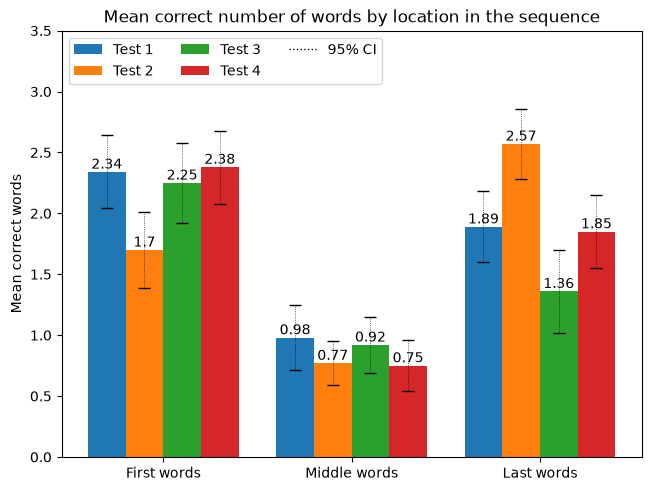

{'Test 1': [0.3, 0.27, 0.29], 'Test 2': [0.31, 0.18, 0.29], 'Test 3': [0.33, 0.23, 0.34], 'Test 4': [0.3, 0.21, 0.3]}


In [38]:
categories=("First words","Middle words", "Last words")
means={}
errors={}
for i in range(4):
    mean_temp=[]
    low_temp=[]
    high_temp=[]
    for j in range(3):
        m,low,high=mean_confidence_interval(clean_data()[j][i])
        m=float(round(m,2))
        low=float(round(low,2))
        high=float(round(high,2))
        mean_temp.append(m)
        low_temp.append(low)
        high_temp.append(high)
    means[f'Test {i+1}']=mean_temp
    errors[f'Test {i+1}']=low_temp

fig, ax = plt.subplots(layout='constrained')

res=ax.grouped_bar(means,tick_labels=categories,group_spacing=1)
for i, container in enumerate(res.bar_containers):
    for j, bar in enumerate(container):
        ax.errorbar(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            yerr=errors[f'Test {i+1}'][j],
            fmt='none',
            color='black',
            capsize=4,
            elinestyle=':',
            elinewidth=0.5
        )

    ax.bar_label(container, padding=0)

ax.set_ylabel('Mean correct words')
ax.set_title('Mean correct number of words by location in the sequence')
ax.legend(
    handles=[
        *ax.get_legend_handles_labels()[0],
        Line2D(
            [0], [0],
            color='black',
            linestyle=':',
            linewidth=1,
            label='95% CI'
        )
    ],
    loc='upper left',
    ncols=3
)
ax.set_ylim(0,3.5)

plt.show()

print(errors)
        

In [51]:
#test 1-4 total means
total=[[],[],[],[]]
i=0
while i<53:
    filename="new_participant_data/participant_"+str(i)+".json"
    results=extract_results(filename)
    for j in range(1,5):
        total[j-1].append(results[j]["total"])
    i+=1

test1=mean_confidence_interval(total[0])
test2=mean_confidence_interval(total[1])
test3=mean_confidence_interval(total[2])
test4=mean_confidence_interval(total[3])

print(f"test1: {float(round(test1[0],2)),float(round(test1[1],2))}",
      f"test2: {float(round(test2[0],2)),float(round(test2[1],2))}",
      f"test3: {float(round(test3[0],2)),float(round(test3[1],2))}",
      f"test4: {float(round(test4[0],2)),float(round(test4[1],2))}",)

test1: (5.21, 0.47) test2: (5.04, 0.49) test3: (4.53, 0.51) test4: (4.98, 0.47)


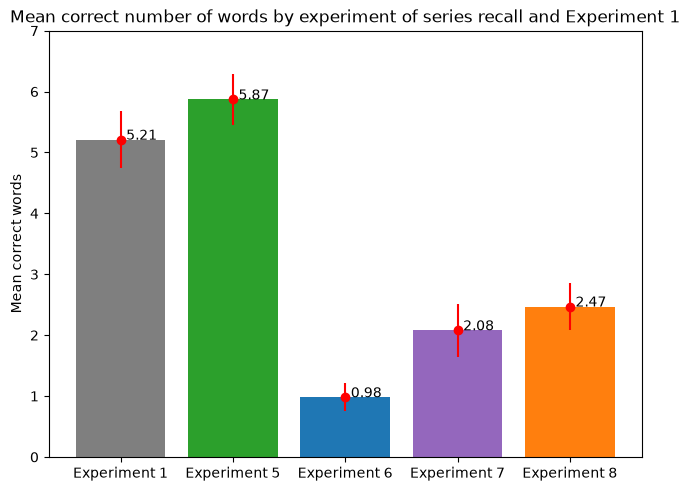

[np.float64(0.4723620476462916),
 np.float64(0.41534709370756456),
 np.float64(0.23244565483157126),
 np.float64(0.43530951536142876),
 np.float64(0.38071824289186396)]

In [52]:
categories=["Experiment 1","Experiment 5","Experiment 6", "Experiment 7","Experiment 8"]
means={}
errors={}
for i in range(4):
    mean_temp=[]
    error_temp=[]
    for j in range(3,4):
        m,low,high=mean_confidence_interval(clean_data()[j][i])
        m=float(round(m,2))
        error=float(round(low,2))
        mean_temp.append(m)
        error_temp.append(low)
    means[f'Experiment {i+1}']=mean_temp
    errors[f'Experiment {i+1}']=error_temp


fig, ax = plt.subplots(layout='constrained')

bar_colors=['tab:grey','tab:green','tab:blue','tab:purple','tab:orange']
meansish=[round(test1[0],2)]
for i in means.values():
    meansish.append(i[0])
errorsies=[test1[1]]
for i in errors.values():
    errorsies.append(i[0])
ax.bar(categories,meansish,color=bar_colors)
ax.errorbar(categories,meansish,yerr=errorsies,fmt="o",color="r")
for i in range(5):
    ax.text(i+0.05,meansish[i],meansish[i])

ax.set_ylabel('Mean correct words')
ax.set_title('Mean correct number of words by experiment of series recall and Experiment 1')

ax.set_ylim(0,7)

plt.show()
errorsies